## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import os

In [8]:
def load_titles(filepath: str) -> pd.DataFrame :
    df = pd.read_csv(filepath)
    df = df[['title', 'label']].rename(columns= {'title':'text'})

    df['label'] = df['label'].map({'REAL' : 1, 'FAKE' : 0})

    df = df.dropna(subset= ['text'])
    df = df[df['text'].str.strip() != ""]

    len_df = len(df)
    nb_rows_by_class = df['label'].value_counts()
    avg_len = df['text'].str.len().mean()

    print("---------- Résumé ----------")
    print(f"Nombre total de titres : {len_df}")
    print(f"Nombre de lignes par classes : {nb_rows_by_class}")
    print(f"Proportions : {df['label'].value_counts(normalize= True) * 100}")
    print(f"Longueur moyenne des titres : { avg_len:.2f} caractères")

    os.makedirs('data', exist_ok=True)
    df.to_csv('../data/titles_clean.csv', index=False)
    print("Fichier sauvegardé dans '../data/titles_clean.csv'")

    return df

df_clean = load_titles("../data/fake_or_real_news.csv")

---------- Résumé ----------
Nombre total de titres : 6335
Nombre de lignes par classes : label
1    3171
0    3164
Name: count, dtype: int64
Proportions : label
1    50.055249
0    49.944751
Name: proportion, dtype: float64
Longueur moyenne des titres : 65.28 caractères
Fichier sauvegardé dans '../data/titles_clean.csv'


### 1.2 Analyse exploratoire
- Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

Répartition des classes :
Classe 1 : 3171 titres (50.1%)
Classe 0 : 3164 titres (49.9%)


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_31376\3350121451.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_clean, palette='viridis')


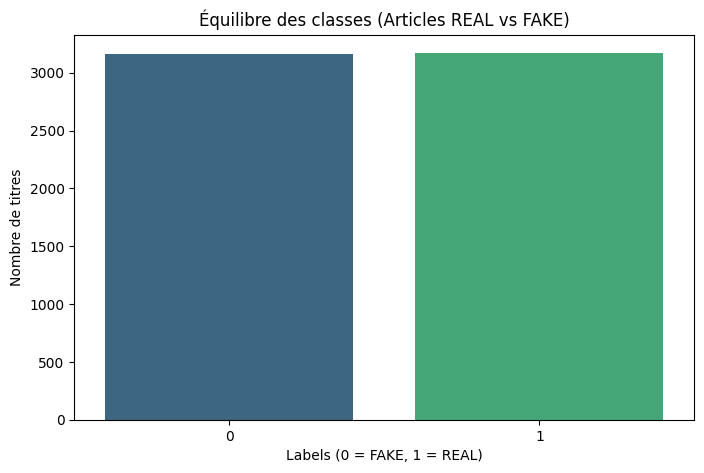

In [13]:
counts = df_clean['label'].value_counts()
percent = df_clean['label'].value_counts(normalize=True) * 100

print("Répartition des classes :")
for label, count in counts.items():
    print(f"Classe {label} : {count} titres ({percent[label]:.1f}%)")

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_clean, palette='viridis')
plt.title('Équilibre des classes (Articles REAL vs FAKE)')
plt.xlabel('Labels (0 = FAKE, 1 = REAL)')
plt.ylabel('Nombre de titres')
plt.show()

Le corpus est bien équilibré, on retrouve environ 50% sur chaque classe 50.1% pour les articles vrais et 49.9% pour les articles faux. 

- Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

In [20]:
avg_len = df_clean['text'].str.len().mean()
min_len = df_clean['text'].str.len().min()
max_len = df_clean['text'].str.len().max()

print(f"La longueur moyenne des critiques est de : {avg_len:.2f} caractères")
print(f"Le titre le plus court contient {min_len} caractères")
print(f"Le titre le plus long contient {max_len} caractères")

La longueur moyenne des critiques est de : 65.28 caractères
Le titre le plus court contient 1 caractères
Le titre le plus long contient 289 caractères


Text(0, 0.5, 'Fréquence')

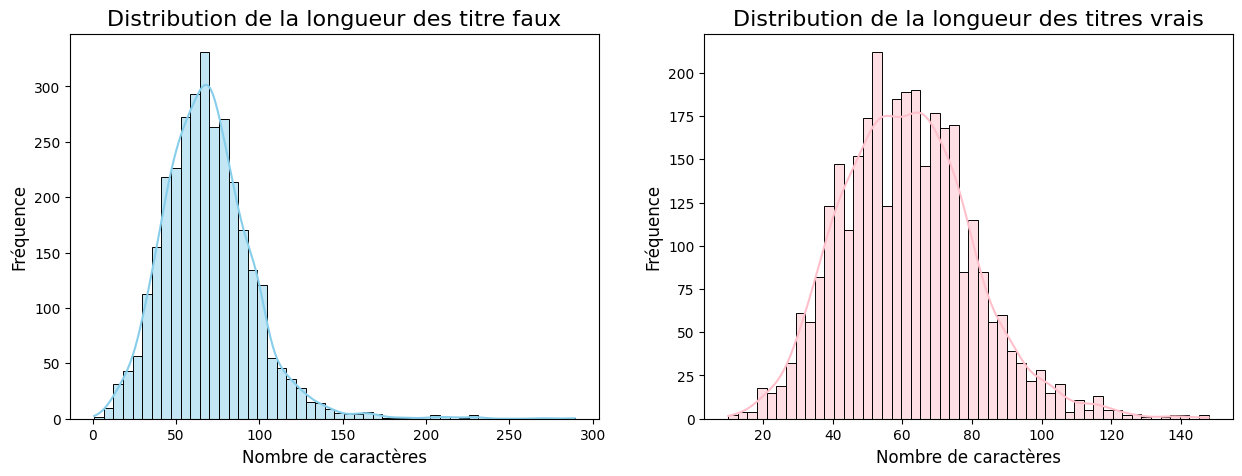

In [18]:
df_clean['title_len'] = df_clean['text'].str.len()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean[df_clean['label'] == 0]['title_len'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Distribution de la longueur des titre faux", fontsize=16)
ax[0].set_xlabel("Nombre de caractères", fontsize=12)
ax[0].set_ylabel("Fréquence", fontsize=12)


sns.histplot(df_clean[df_clean['label'] == 1]['title_len'], bins=50, kde=True, ax=ax[1], color='pink')
ax[1].set_title("Distribution de la longueur des titres vrais", fontsize=16)
ax[1].set_xlabel("Nombre de caractères", fontsize=12)
ax[1].set_ylabel("Fréquence", fontsize=12)

In [25]:
stats_by_class = df_clean.groupby('label')['title_len'].agg(['mean', 'min', 'max', 'median'])

print("Statistiques de longueur par classe :")
print(stats_by_class)

Statistiques de longueur par classe :
            mean  min  max  median
label                             
0      69.180784    1  289    68.0
1      61.383160   10  148    61.0


On peut remarquer avec le graphique que pour les titres Fake, il est plus fréquent d'avoir des longueurs entre 50 et 100 caractères. Tandis que pour les titres REAL, la longueur fréquente des caractères se situe d'avantage entre 40 et 80.

On remarque également dans les statistiques que les titres Fake ont une tendance aux extrêmes avec des titres allant de 1 à 289 caractères. Alors que les titres des articles REAL restent entre 10 et 148.

- Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

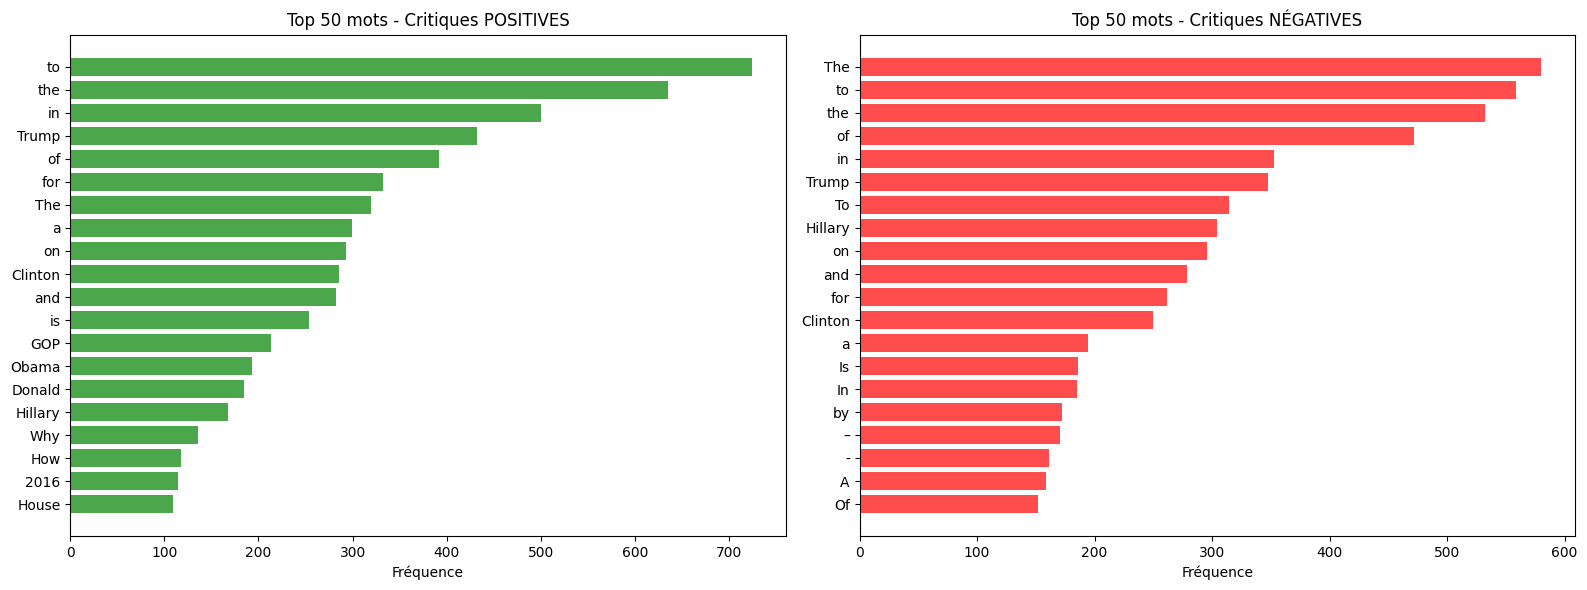

In [ ]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

real_titles = df_clean[df_clean['label'] == 1]['text']
top_positive = get_top_words(real_titles, 20)

fake_title = df_clean[df_clean['label'] == 0]['text']
top_negative = get_top_words(fake_title, 20)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_pos, counts_pos = zip(*top_positive)
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 20 mots - Titres REAL')
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_negative)
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 50 mots - Titres FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

- Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

In [28]:
def get_pure_discriminants(df, top_n=10):
    words_real = set(" ".join(df[df['label'] == 1]['text']).lower().split())
    words_fake = set(" ".join(df[df['label'] == 0]['text']).lower().split())

    pure_real = words_real - words_fake 
    pure_fake = words_fake - words_real

    all_words_real = " ".join(df[df['label'] == 1]['text']).lower().split()
    all_words_fake = " ".join(df[df['label'] == 0]['text']).lower().split()

    count_real = Counter(all_words_real)
    count_fake = Counter(all_words_fake)

    top_pure_real = sorted([(w, count_real[w]) for w in pure_real], key=lambda x: x[1], reverse=True)[:top_n]
    top_pure_fake = sorted([(w, count_fake[w]) for w in pure_fake], key=lambda x: x[1], reverse=True)[:top_n]
    
    return top_pure_real, top_pure_fake


top_real, top_fake = get_pure_discriminants(df_clean)

print("--- Top 10 Tokens Discriminants PURS (REAL) ---")
for word, freq in top_real:
    print(f"{word}: {freq}")

print("\n--- Top 10 Tokens Discriminants PURS (FAKE) ---")
for word, freq in top_fake:
    print(f"{word}: {freq}")

--- Top 10 Tokens Discriminants PURS (REAL) ---
(+video): 67
jeb: 50
marriage: 30
rand: 24
bid: 23
convention: 22
polarization: 20
hampshire: 20
takeaways: 20
nomination: 19

--- Top 10 Tokens Discriminants PURS (FAKE) ---
:: 54
(video): 42
re:: 40
truthfeed: 33
breaking:: 32
finest: 30
[video]: 26
gold: 22
podesta: 18
fraud: 18


On observe bien une différence entre les titres REAL et FAKE. Dans les titres FAKE, on trouve des mots chargés d'émotions ou de conspiration (fraud, gold), on y trouve également truthfeed, connu pour diffuser des infox. Contrairement aux titres REAL où le vocabulaire est plus politique et institutionnel (convention, nomination, hampshire).

On peur remarquer également une différence dans la ponctuation et le formatage. Dans les tokens de la clase FAKE, on remarque beaucoup d'incohérence (::, re:, breaking ::). Il y a également une différence dans le formatage des vidéos : 
- (+video) pour les titres REAL
- (video) pour les titres FAKE


- Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

In [ ]:
words_real = Counter(" ".join(df_clean[df_clean['label'] == 1]['text']).lower().split())
words_fake = Counter(" ".join(df_clean[df_clean['label'] == 0]['text']).lower().split())

def calculate_ambiguity_score(text):
    words = text.lower().split()
    score = 0
    for w in words:
        total = words_real[w] + words_fake[w]
        if total > 10: 
            ratio = words_real[w] / total
            score += abs(ratio - 0.5)
    return score / len(words) if len(words) > 0 else 1

df_clean['ambiguity_score'] = df_clean['text'].apply(calculate_ambiguity_score)
ambiguous_titles = df_clean.sort_values(by='ambiguity_score').head(3)

print(ambiguous_titles[['text', 'label']])

                                                   text  label
2839      (The Onion) Strongside/Weakside: Theo Epstein      0
57                Closed primaries, 'warped' democracy?      1
5678  MUFON International tracking multiple triangle...      0


Voilà les 3 exemples sortis :
- 2839      (The Onion) Strongside/Weakside: Theo Epstein      0
- 57                Closed primaries, 'warped' democracy?      1
- 5678  MUFON International tracking multiple triangle...      0

- Le premier exemple est assez explicite : The Onion est un journal satirique, quand nous le voyons, nous pensons tout de suite que c'est faux. Cependant le titre utilise un vocabulaire analytique sérieux, qui ne montre pas à l'IA que c'est un FAKE. Si le modèle n'a pas appris que le mot clé "The Onion" est un indicateur de parodie, il classera probablement ce titre comme REAL car la structure est propren sans ponctuation excessive no majuscules agressives. 

- Dans le deuxième exemple, l'ambiguïté vient de la ponctuation fortement présente sur un titre aussi court. 

- Concernant le troisième exemple, la structure grammaticale est proche de celle d'une news de la NASA ou du FBI, donc en apparence il s'agit de quelque chose de sérieux. Cependant MUFON concerne le paranormal, il s'agit d'une organisation qui suit les OVNI. 